# Automated Readability Index

$$\textrm{ARI}=4.71\times\frac{\textrm{\# of chars}}{\textrm{\# of words}}
+0.5\times\frac{\textrm{\# of words}}{\textrm{\# of sents}}-21.43$$

In [1]:
import polars as pl
import polars_corpus as plc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
c = pl.read_parquet('brown.parquet')


In [3]:
%%timeit

(
    c.group_by('category', 'file_id')
    .agg(pl.col('token').str.len_chars().sum().alias('chars'),
         pl.len().alias('words'),
         (pl.col('sentence_tag') == 'B').sum().alias('sents'))
    .with_columns((4.71 * pl.col('chars') / pl.col('words') + 0.5 * pl.col('words') / pl.col('sents') - 21.43).alias('ari'))
    .group_by('category').agg(pl.col('ari').mean())
)





7.22 ms ± 133 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [4]:
%%timeit

(
    c.lazy().group_by('category', 'file_id')
    .agg((pl.col('token').n_unique() / pl.len()).alias('ttr'),
         pl.col('token').str.len_chars().sum().alias('chars'),
         pl.len().alias('words'),
         (pl.col('sentence_tag') == 'B').sum().alias('sents'))
    .with_columns(
        (4.71 * pl.col('chars') / pl.col('words') + 0.5 * pl.col('words') / pl.col('sents') - 21.43).alias('ari'))
    .group_by('category').agg(pl.col('ari').mean()).collect(engine='streaming')
)


18.5 ms ± 370 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [5]:
ari = (
    c.group_by('category', 'file_id')
    .agg((pl.col('token').n_unique() / pl.len()).alias('ttr'),
         pl.col('token').str.len_chars().sum().alias('chars'),
         pl.len().alias('words'),
         (pl.col('sentence_tag') == 'B').sum().alias('sents'))
    .with_columns(
        (4.71 * pl.col('chars') / pl.col('words') + 0.5 * pl.col('words') / pl.col('sents') - 21.43).alias('ari'))
)


<Axes: xlabel='ari', ylabel='category'>

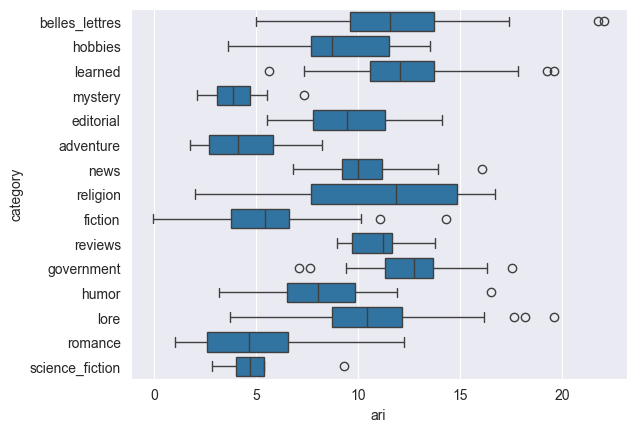

In [6]:
sns.boxplot(data=ari,y='category',x='ari')

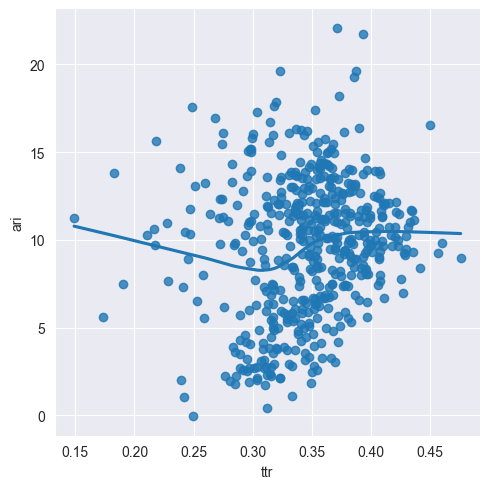

In [9]:
sns.lmplot(data=ari,x='ttr',y='ari',lowess=True)

In [8]:
c.filter(pl.col('file_id') == 'ck24')

token,tag,sentence_tag,file_id,category
str,str,str,str,str
"""His""","""PP$""","""B""","""ck24""","""fiction"""
"""eyes""","""NNS""","""I""","""ck24""","""fiction"""
"""were""","""BED""","""I""","""ck24""","""fiction"""
"""old""","""JJ""","""I""","""ck24""","""fiction"""
"""and""","""CC""","""I""","""ck24""","""fiction"""
…,…,…,…,…
"""arm""","""NN""","""I""","""ck24""","""fiction"""
"""behind""","""IN""","""I""","""ck24""","""fiction"""
"""his""","""PP$""","""I""","""ck24""","""fiction"""
